# QResP — Quantum-Resilient Provenance Audit: Analysis

**CS F376 Design Project · BITS Pilani Dubai Campus · 2025–26**  
Supervisor: Dr. Tamizharasan Periyasamy

This notebook reproduces all figures and tables for the project report from the 1,000-model HuggingFace audit dataset.

---

## 0. Setup

In [1]:
import sys
print(sys.executable)

c:\Users\dell\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import json
import math
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np

# Aesthetics
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

# Colour palette
C = {
    'unsigned':   '#CBD5E1',  # slate-300
    'vulnerable': '#F97316',  # orange-500
    'safe':       '#22C55E',  # green-500
    'mixed':      '#A855F7',  # purple-500
    'error':      '#EF4444',  # red-500
    'accent':     '#0EA5E9',  # sky-500
    'dark':       '#1E293B',  # slate-800
}

print('Setup complete.')

Setup complete.


## 1. Load Dataset

In [3]:
import json
from pathlib import Path

NOTEBOOK_DIR = Path(__file__).parent if '__file__' in locals() else Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / 'data' / 'full.jsonl'

print(f'Kernel running from: {Path().resolve()}')
print(f'Looking for data at: {DATA_PATH}')
print(f'File exists: {DATA_PATH.exists()}')

records = []
with open(DATA_PATH) as f:
    for line in f:
        records.append(json.loads(line.strip()))

df = pd.DataFrame(records)
df['last_modified'] = pd.to_datetime(df['last_modified'])
df['audit_ts'] = pd.to_datetime(df['audit_ts'])
df['year'] = df['last_modified'].dt.year

print(f'Loaded {len(df):,} records')
print(f'Date range: {df["last_modified"].min().date()} — {df["last_modified"].max().date()}')
df[['model_id', 'publisher', 'downloads', 'q_label', 'sig_algorithm']].head()

Kernel running from: C:\Users\dell\Desktop\Projects\Design project\qresp\qresp\notebooks
Looking for data at: C:\Users\dell\Desktop\Projects\Design project\qresp\qresp\data\full.jsonl
File exists: True
Loaded 1,000 records
Date range: 2020-12-11 — 2026-05-21


,model_id,publisher,downloads,q_label,sig_algorithm
0,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers,259600864,unsigned,none
1,Qwen/Qwen3-VL-2B-Instruct,Qwen,116430439,unsigned,none
2,google-bert/bert-base-uncased,google-bert,68788715,unsigned,none
3,cross-encoder/ms-marco-MiniLM-L6-v2,cross-encoder,57198263,unsigned,none
4,google/electra-base-discriminator,google,56217353,unsigned,none


## 2. Statistical Inference

In [4]:
def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = z * math.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return max(0, centre - margin), min(1, centre + margin)

n = len(df)
counts = df['q_label'].value_counts()

stats = {}
for label in ['unsigned', 'vulnerable', 'safe', 'mixed', 'error']:
    k = counts.get(label, 0)
    lo, hi = wilson_ci(k, n)
    stats[label] = {'count': k, 'pct': 100*k/n, 'ci_lo': 100*lo, 'ci_hi': 100*hi}

stats_df = pd.DataFrame(stats).T
stats_df['count'] = stats_df['count'].astype(int)
print(f'n = {n}\n')
print(stats_df.round(3).to_string())

n = 1000

            count   pct   ci_lo   ci_hi
unsigned      998  99.8  99.274  99.945
vulnerable      2   0.2   0.055   0.726
safe            0   0.0   0.000   0.383
mixed           0   0.0   0.000   0.383
error           0   0.0   0.000   0.383


## 3. Figure 1 — Quantum Vulnerability Distribution (Donut Chart)

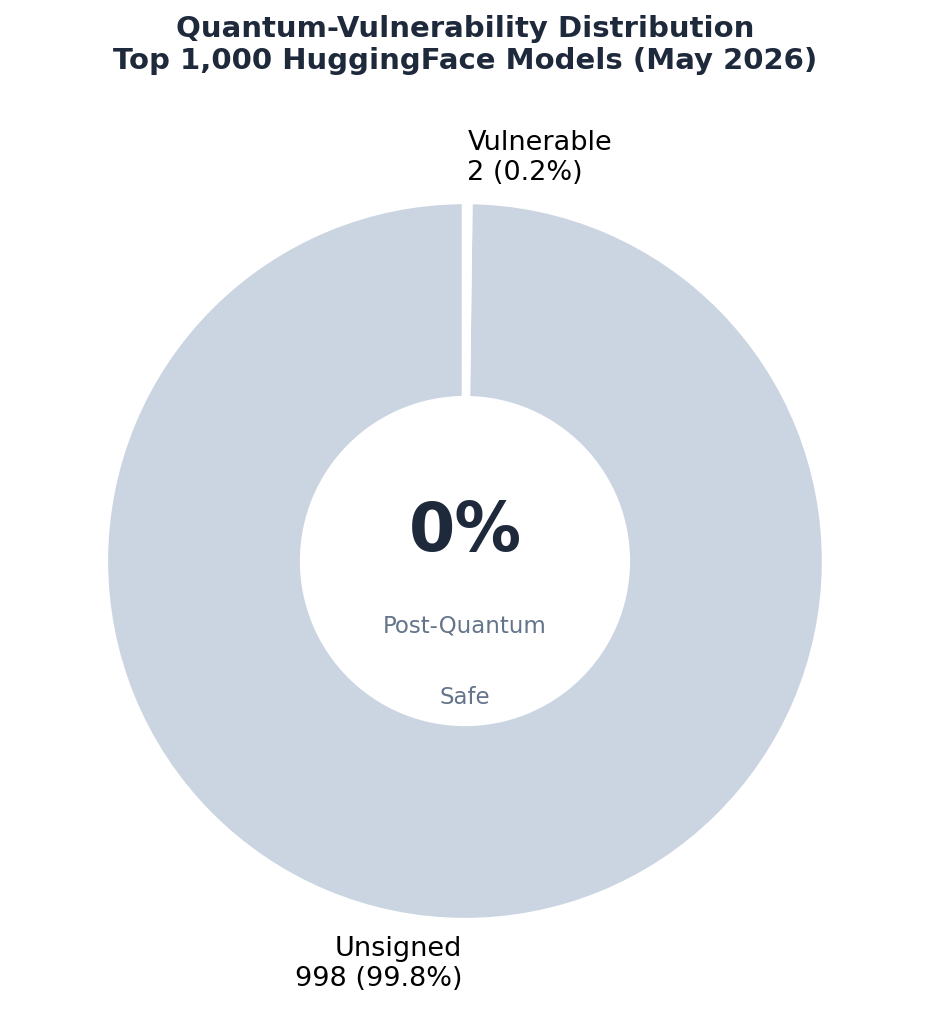

Saved → docs/fig1_donut.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

labels_order = ['unsigned', 'vulnerable']
sizes  = [stats[l]['count'] for l in labels_order]
colors = [C[l] for l in labels_order]
display_labels = [
    f"Unsigned\n998 (99.8%)",
    f"Vulnerable\n2 (0.2%)",
]

wedges, texts = ax.pie(
    sizes,
    labels=display_labels,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=13),
    labeldistance=1.12,
)

# Centre annotation
ax.text(0, 0.08, '0%', ha='center', va='center', fontsize=32, fontweight='bold', color=C['dark'])
ax.text(0, -0.18, 'Post-Quantum', ha='center', va='center', fontsize=11, color='#64748B')
ax.text(0, -0.38, 'Safe', ha='center', va='center', fontsize=11, color='#64748B')

ax.set_title(
    'Quantum-Vulnerability Distribution\nTop 1,000 HuggingFace Models (May 2026)',
    fontsize=14, fontweight='bold', pad=20, color=C['dark']
)

plt.tight_layout()
plt.savefig('../docs/fig1_donut.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig1_donut.png')

## 4. Figure 2 — Wilson Confidence Intervals (Forest Plot)

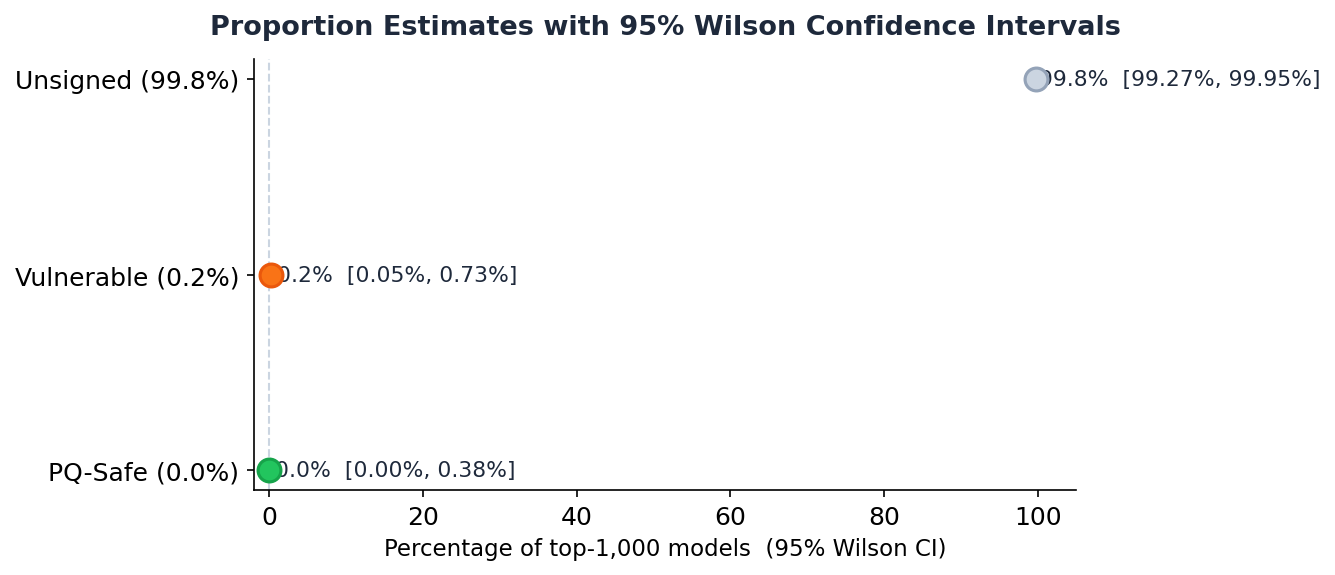

Saved → docs/fig2_forest.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))

rows = [
    ('Unsigned (99.8%)',   stats['unsigned'],   C['unsigned'],   '#94A3B8'),
    ('Vulnerable (0.2%)',  stats['vulnerable'], C['vulnerable'], '#EA580C'),
    ('PQ-Safe (0.0%)',     stats['safe'],       C['safe'],       '#16A34A'),
]

y_positions = list(range(len(rows)))

for y, (label, s, color, ecolor) in zip(y_positions, rows):
    mid = s['pct']
    lo  = s['ci_lo']
    hi  = s['ci_hi']
    ax.plot([lo, hi], [y, y], color=ecolor, linewidth=3, solid_capstyle='round')
    ax.scatter([mid], [y], color=color, s=120, zorder=5, edgecolors=ecolor, linewidth=1.5)
    ax.text(hi + 0.3, y, f'{mid:.1f}%  [{lo:.2f}%, {hi:.2f}%]',
            va='center', fontsize=10.5, color=C['dark'])

ax.set_yticks(y_positions)
ax.set_yticklabels([r[0] for r in rows], fontsize=12)
ax.set_xlabel('Percentage of top-1,000 models  (95% Wilson CI)', fontsize=11)
ax.set_xlim(-2, 105)
ax.axvline(0, color='#CBD5E1', linewidth=1, linestyle='--')
ax.set_title('Proportion Estimates with 95% Wilson Confidence Intervals',
             fontsize=13, fontweight='bold', pad=12, color=C['dark'])
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../docs/fig2_forest.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig2_forest.png')

## 5. Figure 3 — Downloads Covered (Cumulative Reach)

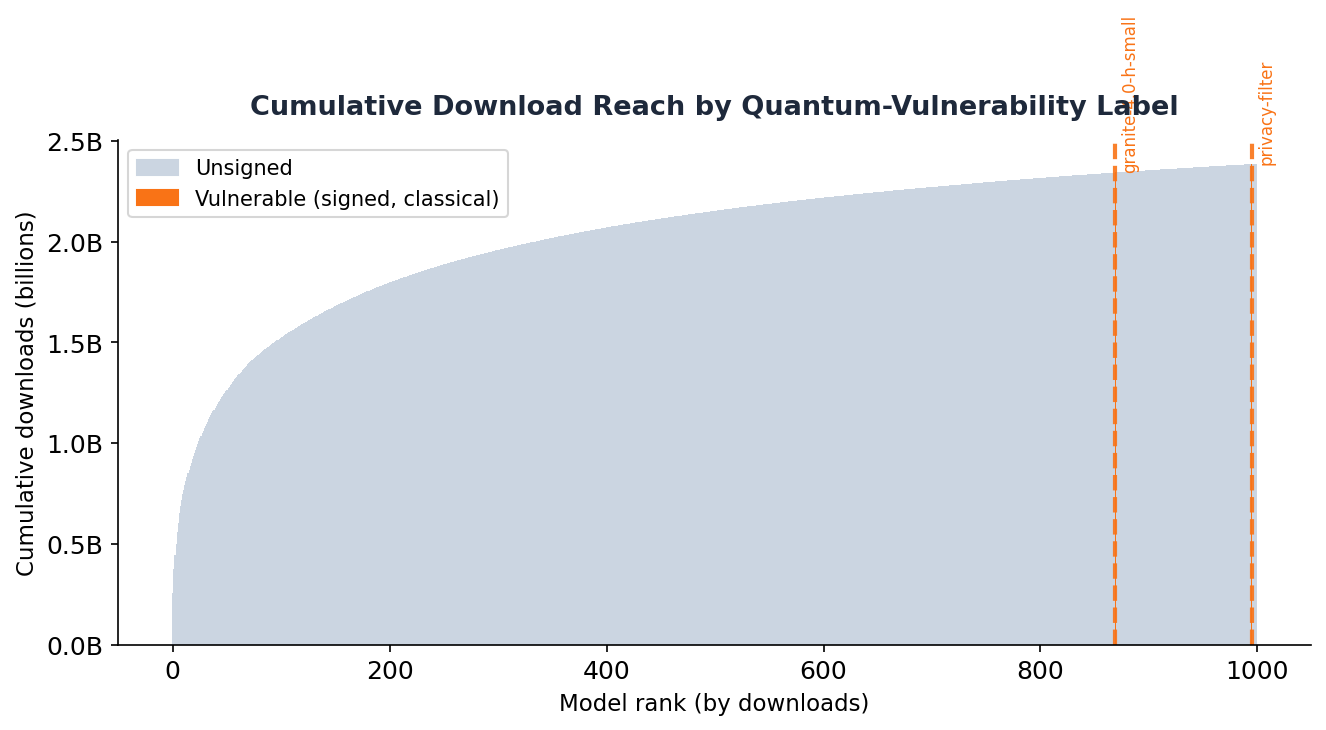

Saved → docs/fig3_cumulative.png


In [7]:
df_sorted = df.sort_values('downloads', ascending=False).reset_index(drop=True)
df_sorted['cumulative_downloads'] = df_sorted['downloads'].cumsum() / 1e9  # billions

fig, ax = plt.subplots(figsize=(9, 5))

# Shade by label
for i, row in df_sorted.iterrows():
    ax.bar(i, row['cumulative_downloads'], color=C.get(row['q_label'], '#CBD5E1'),
           width=1.0, linewidth=0)

# Mark the 2 signed models
signed_idx = df_sorted[df_sorted['has_signature']].index.tolist()
for idx in signed_idx:
    ax.axvline(idx, color=C['vulnerable'], linewidth=2, linestyle='--', alpha=0.9)
    ax.text(idx + 5, df_sorted.loc[idx, 'cumulative_downloads'],
            df_sorted.loc[idx, 'model_id'].split('/')[-1],
            fontsize=8, color=C['vulnerable'], rotation=90, va='bottom')

legend_patches = [
    mpatches.Patch(color=C['unsigned'],   label='Unsigned'),
    mpatches.Patch(color=C['vulnerable'], label='Vulnerable (signed, classical)'),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10)

ax.set_xlabel('Model rank (by downloads)', fontsize=11)
ax.set_ylabel('Cumulative downloads (billions)', fontsize=11)
ax.set_title('Cumulative Download Reach by Quantum-Vulnerability Label',
             fontsize=13, fontweight='bold', pad=12, color=C['dark'])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fB'))

plt.tight_layout()
plt.savefig('../docs/fig3_cumulative.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig3_cumulative.png')

## 6. Figure 4 — Publisher Breakdown (Top 20)

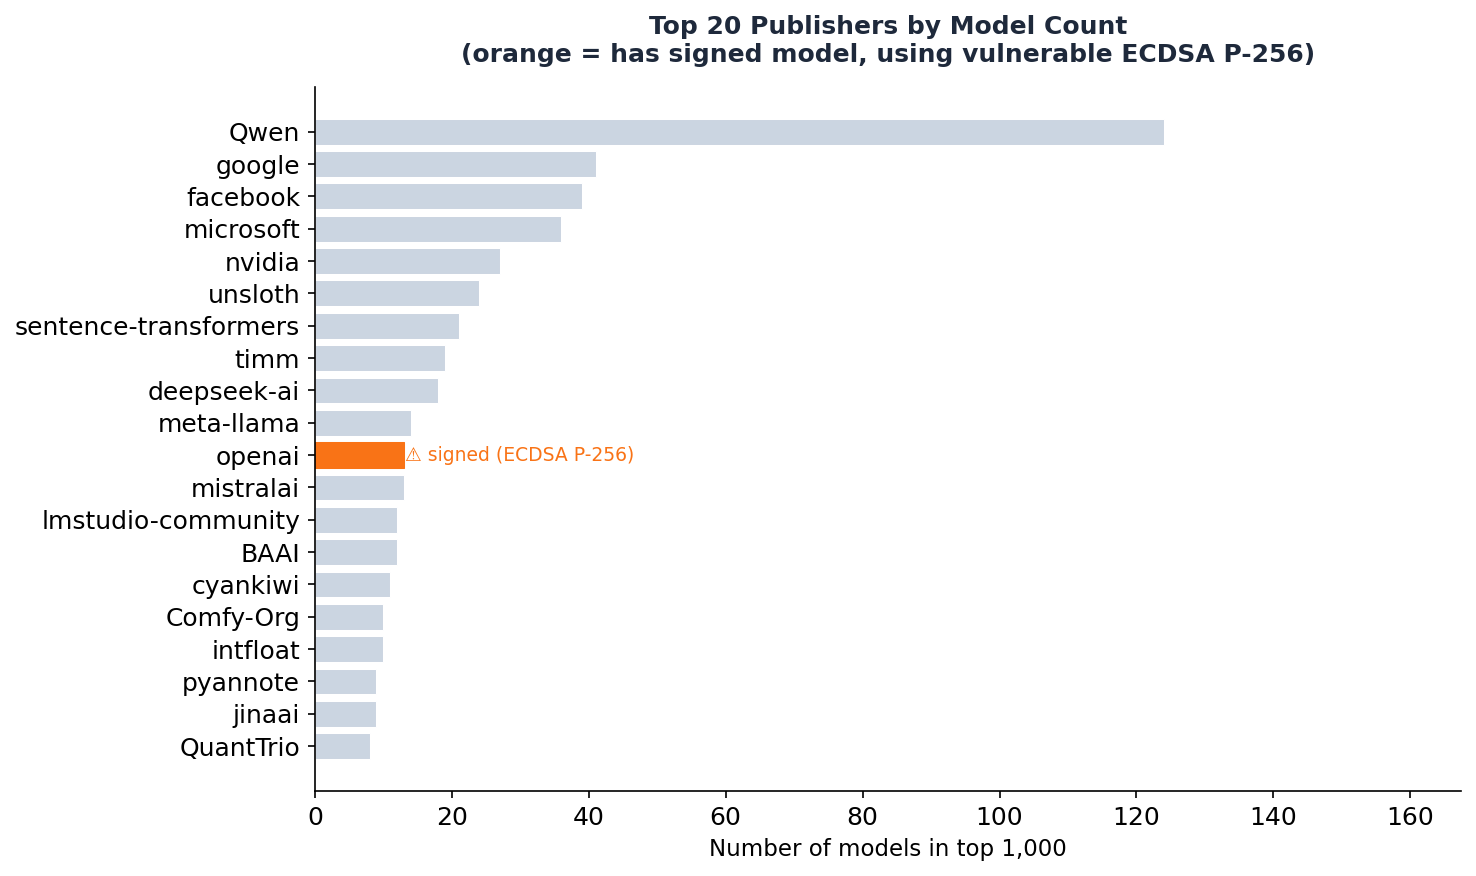

Saved → docs/fig4_publishers.png


In [8]:
pub_counts = df.groupby('publisher')['model_id'].count().sort_values(ascending=False).head(20)
pub_signed = df[df['has_signature']].groupby('publisher')['model_id'].count()

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(pub_counts.index[::-1], pub_counts.values[::-1],
               color=C['unsigned'], edgecolor='white', linewidth=0.5)

# Highlight publishers with signed models
for i, pub in enumerate(pub_counts.index[::-1]):
    if pub in pub_signed.index:
        bars[i].set_color(C['vulnerable'])
        ax.text(pub_counts[pub] + 0.2, i, '⚠ signed (ECDSA P-256)',
                va='center', fontsize=9, color=C['vulnerable'])

ax.set_xlabel('Number of models in top 1,000', fontsize=11)
ax.set_title('Top 20 Publishers by Model Count\n(orange = has signed model, using vulnerable ECDSA P-256)',
             fontsize=12, fontweight='bold', pad=12, color=C['dark'])
ax.set_xlim(0, pub_counts.max() * 1.35)

plt.tight_layout()
plt.savefig('../docs/fig4_publishers.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig4_publishers.png')

## 7. Figure 5 — Models by Last-Modified Year

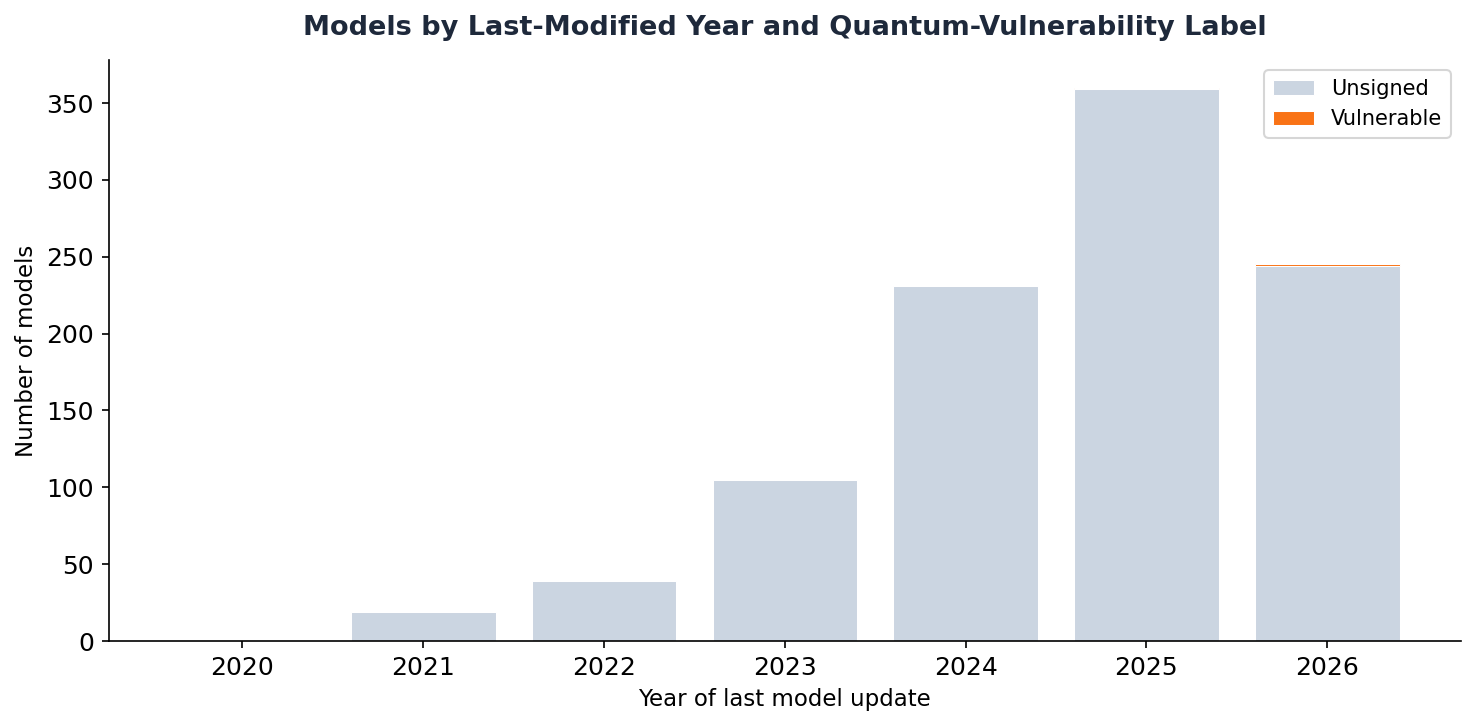

Saved → docs/fig5_by_year.png


In [9]:
year_label = df.groupby(['year', 'q_label']).size().unstack(fill_value=0)
years = sorted(df['year'].dropna().unique().astype(int))

fig, ax = plt.subplots(figsize=(10, 5))

bottom = np.zeros(len(years))
for label in ['unsigned', 'vulnerable', 'safe']:
    if label in year_label.columns:
        vals = [year_label.loc[y, label] if y in year_label.index else 0 for y in years]
        ax.bar(years, vals, bottom=bottom, color=C[label], label=label.capitalize(),
               edgecolor='white', linewidth=0.5)
        bottom += np.array(vals)

ax.set_xlabel('Year of last model update', fontsize=11)
ax.set_ylabel('Number of models', fontsize=11)
ax.set_title('Models by Last-Modified Year and Quantum-Vulnerability Label',
             fontsize=13, fontweight='bold', pad=12, color=C['dark'])
ax.legend(fontsize=10)
ax.set_xticks(years)

plt.tight_layout()
plt.savefig('../docs/fig5_by_year.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig5_by_year.png')

## 8. Figure 6 — Power Analysis Curve

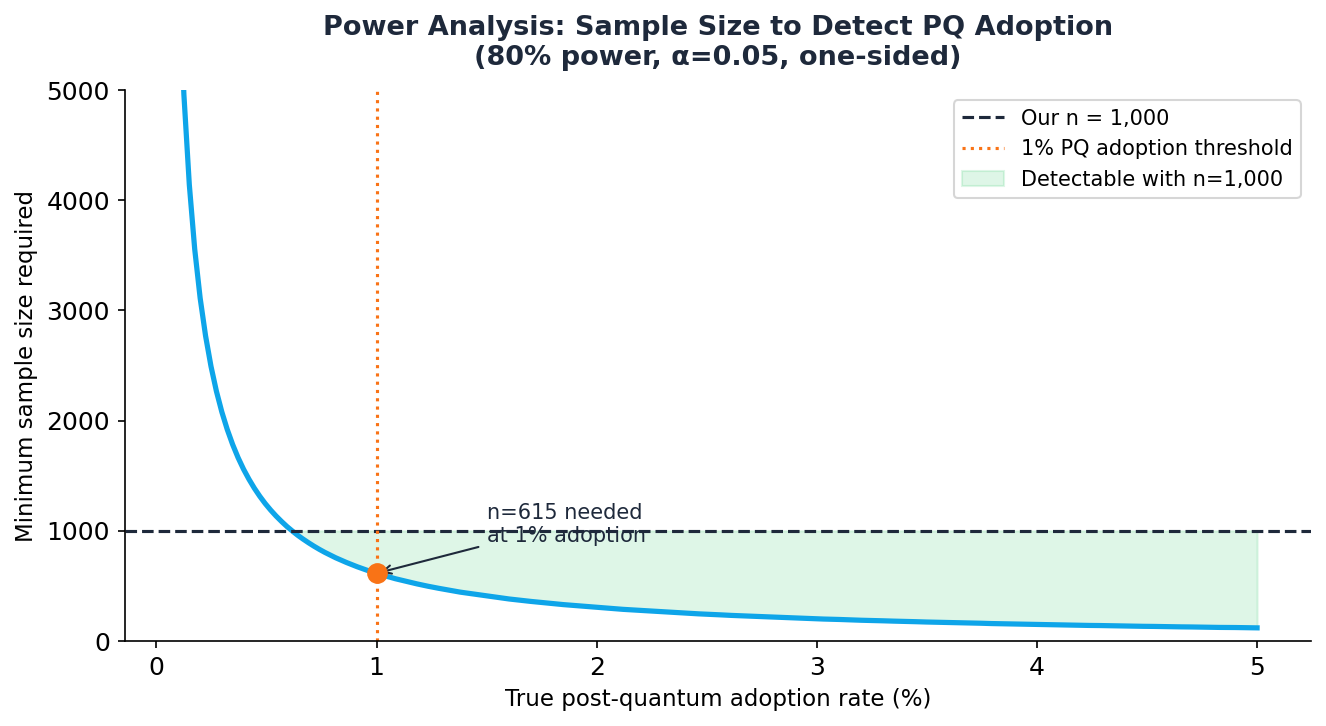

Saved → docs/fig6_power.png


In [10]:
def min_n_to_detect(p1, alpha=0.05, power=0.80):
    """Minimum n to detect proportion p1 vs p0=0 (one-sided z-test)."""
    z_alpha = 1.645
    z_beta  = 0.842
    p0 = 0.0
    p_bar = (p0 + p1) / 2
    if p1 == 0:
        return float('inf')
    n = ((z_alpha * math.sqrt(2 * p_bar * (1 - p_bar)) +
          z_beta  * math.sqrt(p0*(1-p0) + p1*(1-p1))) / (p1 - p0)) ** 2
    return math.ceil(n)

target_rates = np.linspace(0.001, 0.05, 200)  # 0.1% to 5%
n_needed = [min_n_to_detect(p) for p in target_rates]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(target_rates * 100, n_needed, color=C['accent'], linewidth=2.5)
ax.axhline(1000, color=C['dark'], linewidth=1.5, linestyle='--', label='Our n = 1,000')
ax.axvline(1.0,  color=C['vulnerable'], linewidth=1.5, linestyle=':', label='1% PQ adoption threshold')

# Mark n=615 at p=1%
ax.scatter([1.0], [615], color=C['vulnerable'], s=80, zorder=5)
ax.annotate('n=615 needed\nat 1% adoption', xy=(1.0, 615), xytext=(1.5, 900),
            arrowprops=dict(arrowstyle='->', color=C['dark']),
            fontsize=10, color=C['dark'])

ax.fill_between(target_rates * 100, n_needed, 1000,
                where=[n <= 1000 for n in n_needed],
                alpha=0.15, color=C['safe'], label='Detectable with n=1,000')

ax.set_xlabel('True post-quantum adoption rate (%)', fontsize=11)
ax.set_ylabel('Minimum sample size required', fontsize=11)
ax.set_title('Power Analysis: Sample Size to Detect PQ Adoption\n(80% power, α=0.05, one-sided)',
             fontsize=13, fontweight='bold', pad=12, color=C['dark'])
ax.legend(fontsize=10)
ax.set_ylim(0, 5000)

plt.tight_layout()
plt.savefig('../docs/fig6_power.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → docs/fig6_power.png')

## 9. Figure 7 — Summary Infographic

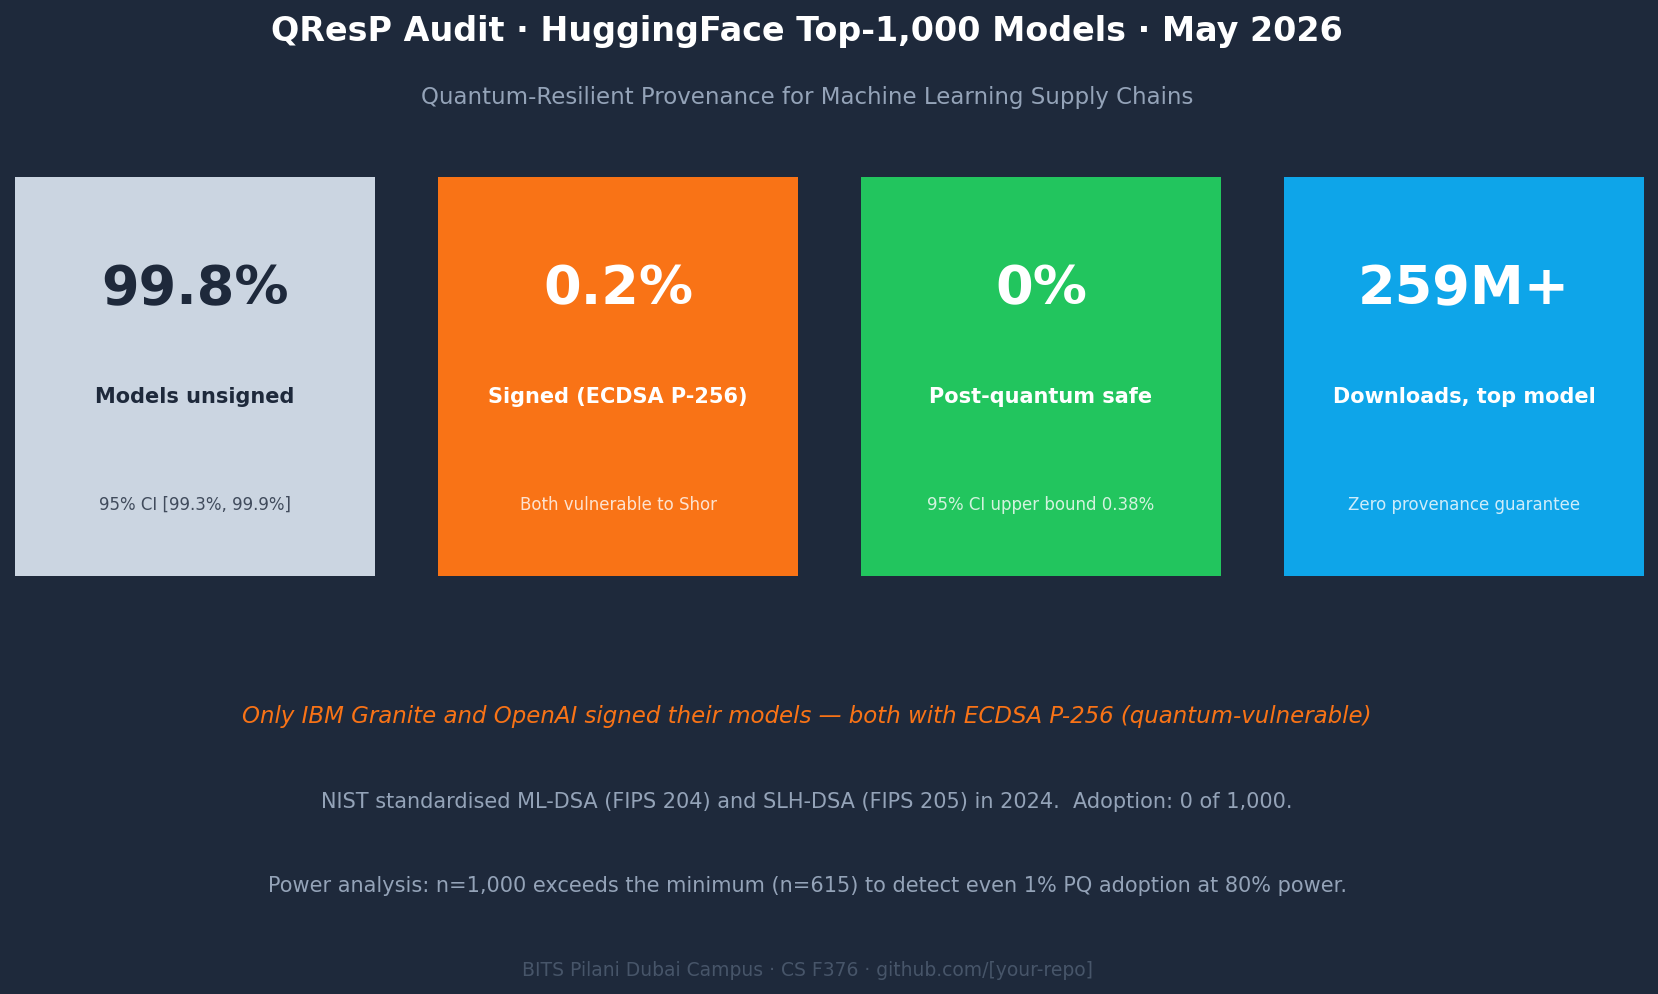

Saved → docs/fig7_infographic.png


In [11]:
fig = plt.figure(figsize=(12, 7))
fig.patch.set_facecolor(C['dark'])

# Title
fig.text(0.5, 0.93, 'QResP Audit · HuggingFace Top-1,000 Models · May 2026',
         ha='center', fontsize=16, fontweight='bold', color='white')
fig.text(0.5, 0.87, 'Quantum-Resilient Provenance for Machine Learning Supply Chains',
         ha='center', fontsize=11, color='#94A3B8')

# Stat boxes
box_data = [
    ('99.8%',  'Models unsigned',         '95% CI [99.3%, 99.9%]', '#CBD5E1', C['dark']),
    ('0.2%',   'Signed (ECDSA P-256)',     'Both vulnerable to Shor',  '#F97316', 'white'),
    ('0%',     'Post-quantum safe',        '95% CI upper bound 0.38%', '#22C55E', 'white'),
    ('259M+',  'Downloads, top model',     'Zero provenance guarantee', '#0EA5E9', 'white'),
]

for i, (big, mid, small, bg, fg) in enumerate(box_data):
    x = 0.06 + i * 0.235
    ax_box = fig.add_axes([x, 0.42, 0.20, 0.38])
    ax_box.set_facecolor(bg)
    ax_box.set_xticks([])
    ax_box.set_yticks([])
    for spine in ax_box.spines.values():
        spine.set_visible(False)
    ax_box.text(0.5, 0.72, big,  ha='center', va='center', fontsize=26,
                fontweight='bold', color=fg, transform=ax_box.transAxes)
    ax_box.text(0.5, 0.45, mid,  ha='center', va='center', fontsize=10,
                fontweight='bold', color=fg, transform=ax_box.transAxes, wrap=True)
    ax_box.text(0.5, 0.18, small, ha='center', va='center', fontsize=8,
                color=fg, alpha=0.8, transform=ax_box.transAxes, wrap=True)

# Bottom key finding
fig.text(0.5, 0.28,
         'Only IBM Granite and OpenAI signed their models — both with ECDSA P-256 (quantum-vulnerable)',
         ha='center', fontsize=11, color='#F97316', fontstyle='italic')

fig.text(0.5, 0.20,
         'NIST standardised ML-DSA (FIPS 204) and SLH-DSA (FIPS 205) in 2024.  Adoption: 0 of 1,000.',
         ha='center', fontsize=10, color='#94A3B8')

fig.text(0.5, 0.12,
         'Power analysis: n=1,000 exceeds the minimum (n=615) to detect even 1% PQ adoption at 80% power.',
         ha='center', fontsize=10, color='#94A3B8')

fig.text(0.5, 0.04,
         'BITS Pilani Dubai Campus · CS F376 · github.com/[your-repo]',
         ha='center', fontsize=9, color='#475569')

plt.savefig('../docs/fig7_infographic.png', bbox_inches='tight', dpi=200,
            facecolor=C['dark'])
plt.show()
print('Saved → docs/fig7_infographic.png')

## 10. Summary Table

In [12]:
# Signed model details
signed_df = df[df['has_signature']][[
    'model_id', 'publisher', 'downloads', 'last_modified',
    'sig_algorithm', 'sig_format', 'q_label'
]].copy()
signed_df['downloads'] = signed_df['downloads'].apply(lambda x: f'{x:,}')
signed_df['last_modified'] = signed_df['last_modified'].dt.date
print('=== Signed Models ===')
print(signed_df.to_string(index=False))

print()
print('=== Top 10 unsigned models by downloads ===')
top_unsigned = df[df['q_label'] == 'unsigned'].nlargest(10, 'downloads')[[
    'model_id', 'publisher', 'downloads'
]].copy()
top_unsigned['downloads'] = top_unsigned['downloads'].apply(lambda x: f'{x:,}')
print(top_unsigned.to_string(index=False))

print()
total_dl = df['downloads'].sum()
unsigned_dl = df[df['q_label']=='unsigned']['downloads'].sum()
print(f'Total downloads across corpus:    {total_dl:>15,}')
print(f'Downloads with no provenance:     {unsigned_dl:>15,}  ({100*unsigned_dl/total_dl:.1f}%)')

=== Signed Models ===
                       model_id   publisher downloads last_modified sig_algorithm sig_format    q_label
ibm-granite/granite-4.0-h-small ibm-granite   365,180    2025-11-03    ecdsa_p256   sigstore vulnerable
          openai/privacy-filter      openai   297,073    2026-04-22    ecdsa_p256   sigstore vulnerable

=== Top 10 unsigned models by downloads ===
                                                   model_id             publisher   downloads
                     sentence-transformers/all-MiniLM-L6-v2 sentence-transformers 259,600,864
                                  Qwen/Qwen3-VL-2B-Instruct                  Qwen 116,430,439
                              google-bert/bert-base-uncased           google-bert  68,788,715
                        cross-encoder/ms-marco-MiniLM-L6-v2         cross-encoder  57,198,263
                          google/electra-base-discriminator                google  56,217,353
sentence-transformers/paraphrase-multilingual-MiniLM-L12-